# Module 9: Growing Self-Avoiding Walks

An ordinary random walk chooses each new step independently of the past. A growing self-avoiding walk changes this rule: the path is not allowed to visit a lattice site that has already been visited.

This exploratory module extends the random walk idea. We use simulation to study path dependence, trapping, and the difference between one sample path and many repeated simulations.

## Model

The walk starts at the origin $(0,0)$ on the square lattice $\mathbb{Z}^2$. At a site $(x,y)$, the four possible nearest-neighbour sites are $(x+1,y)$, $(x-1,y)$, $(x,y+1)$, and $(x,y-1)$.

A site is allowed only if it has not been visited before. At each step, if at least one allowed neighbour exists, the walk must move to one of the allowed neighbours, chosen uniformly at random. If no allowed neighbour exists, the walk is trapped and the simulation stops.

This is a growing self-avoiding walk. It is different from choosing uniformly from all self-avoiding paths of a fixed length.

### Markov property

The ordinary random walk is Markov when the current position is known. For the growing self-avoiding walk, the current position alone is not enough to determine the distribution of the next step.

Two paths may end at the same lattice site but have different visited sets. Their allowed next moves may therefore be different. For this reason, the position process alone is not a Markov chain.

If the state is enlarged to include both the current position and the set of visited sites, then the simulation rule becomes Markov in this enlarged state space.

### Simulation rule

Start from $(0,0)$ and store all visited lattice sites. At each step, list the unvisited nearest neighbours of the current site. If no such neighbour exists, stop the walk. Otherwise choose one available neighbour uniformly at random, move there, and add it to the set of visited sites. The recorded path is therefore self avoiding by construction.


## Libraries

We first import the libraries used in this module. NumPy is used to choose random moves, store paths, and repeat the experiment many times. Matplotlib is used to show lattice paths and summaries of stopping length and final distance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Use the same plotting style throughout the module
FIGSIZE = (8, 4.5)
HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

plt.rcParams["lines.markersize"] = 4

### Helper functions

The following functions simulate paths, compute simple path statistics, and draw lattice paths.

In [3]:
def simulate_growing_self_avoiding_walk(n_steps, start=(0, 0), rng=None):
    """Simulate a growing self-avoiding walk on the square lattice."""
    if rng is None:
        rng = np.random.default_rng()

    path = [start]
    visited = {start}

    for _ in range(n_steps):
        x, y = path[-1]

        # Nearest neighbours
        neighbours = [
            (x + 1, y),
            (x - 1, y),
            (x, y + 1),
            (x, y - 1),
        ]

        # Keep only unvisited neighbours
        available = [site for site in neighbours if site not in visited]

        # Stop if no legal move exists
        if len(available) == 0:
            break

        # Choose one legal move
        next_site = available[rng.integers(len(available))]
        path.append(next_site)
        visited.add(next_site)

    return np.array(path)

def simulate_random_walk_2d(n_steps, start=(0, 0), rng=None):
    """Simulate an ordinary nearest-neighbour random walk."""
    if rng is None:
        rng = np.random.default_rng()

    path = [start]
    x, y = start

    for _ in range(n_steps):
        step = rng.integers(4)

        # Choose one of four directions
        if step == 0:
            x = x + 1
        elif step == 1:
            x = x - 1
        elif step == 2:
            y = y + 1
        else:
            y = y - 1

        path.append((x, y))

    return np.array(path)

def stopping_length(path):
    """Return the number of completed steps."""
    return len(path) - 1

def is_trapped(path):
    """Check whether the endpoint has no unvisited neighbour."""
    # Rebuild the visited set from the recorded path
    visited = {tuple(site) for site in path}
    x, y = path[-1]

    neighbours = [
        (x + 1, y),
        (x - 1, y),
        (x, y + 1),
        (x, y - 1),
    ]

    # The walk is trapped when every possible move returns to an old site
    return all(site in visited for site in neighbours)

def final_distance(path):
    """Return the distance from the endpoint to the origin."""
    x, y = path[-1]
    return np.sqrt(x**2 + y**2)

def count_distinct_sites(path):
    """Return the number of distinct sites in a path."""
    sites = [tuple(site) for site in path]
    return len(set(sites))

def check_nearest_neighbour_moves(path):
    """Check that every step is a nearest-neighbour move."""
    differences = np.diff(path, axis=0)
    step_lengths = np.abs(differences).sum(axis=1)
    return np.all(step_lengths == 1)

def plot_lattice_path(path, title):
    """Plot one lattice path."""
    plt.figure(figsize=FIGSIZE)

    # Draw the path and identify its two endpoints
    plt.plot(path[:, 0], path[:, 1], "o-", linewidth=1)
    plt.scatter(path[0, 0], path[0, 1], s=60, label="start")
    plt.scatter(path[-1, 0], path[-1, 1], s=60, label="end")

    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Example 1: One growing self-avoiding path

A single simulation gives one sample path. The path starts at the origin and grows step by step on the square lattice.

At each step, the walk must move to an unvisited nearest neighbour if one exists. If all four nearest neighbours have already been visited, the walk is trapped and the simulation stops.

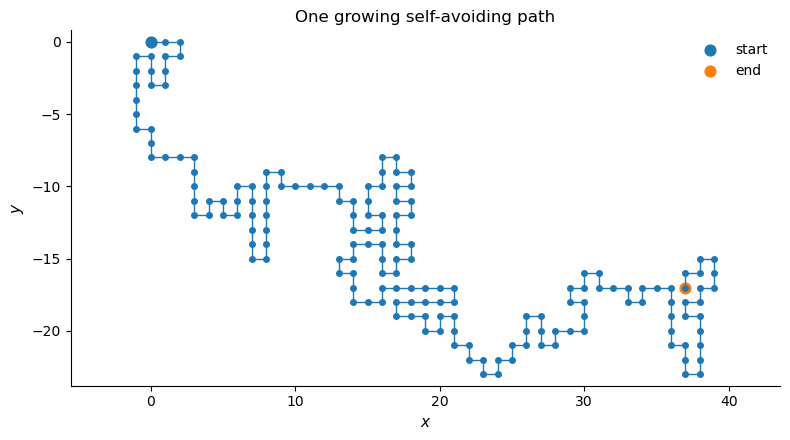

Number of visited sites: 169
Number of completed steps: 168
All moves are nearest-neighbour moves: True


In [4]:
# Simulate one path and inspect its basic properties
example_rng = np.random.default_rng()

path_saw = simulate_growing_self_avoiding_walk(
    n_steps=200,
    rng=example_rng
)

plot_lattice_path(path_saw, "One growing self-avoiding path")

# Report the path length and nearest-neighbour check
print("Number of visited sites:", len(path_saw))
print("Number of completed steps:", stopping_length(path_saw))
print("All moves are nearest-neighbour moves:", check_nearest_neighbour_moves(path_saw))

This is one sample path, not a distribution. The path visits each site at most once, and the check confirms that each step is a nearest neighbour move. If fewer than 200 steps are completed, the walk was trapped before the step limit.


## Task 1: Check self-avoidance

Use the path from Example 1 and check that the number of distinct visited sites is equal to the number of recorded sites in the path. What does this say about the path?

In [5]:
# Check that len(path_saw) equals count_distinct_sites(path_saw).

### Solution

For a self-avoiding path, no site should appear twice. Therefore, the number of distinct visited sites should be the same as the number of recorded sites in the path.

In [6]:
# Compare the recorded sites with the unique lattice sites
number_of_recorded_sites = len(path_saw)
number_of_distinct_sites = count_distinct_sites(path_saw)

print("Recorded sites:", number_of_recorded_sites)
print("Distinct sites:", number_of_distinct_sites)
print("Self-avoiding:", number_of_recorded_sites == number_of_distinct_sites)

Recorded sites: 169
Distinct sites: 169
Self-avoiding: True


The two numbers are equal because the path never visits the same lattice site twice. This is the defining feature of the growing self-avoiding walk.

## Example 2: Comparing with an ordinary random walk

The ordinary random walk and the growing self-avoiding walk both move on the same square lattice, but they use different movement rules.

The ordinary random walk may return to a site that has already been visited. The growing self-avoiding walk cannot do this, so its available moves depend on the whole path history.

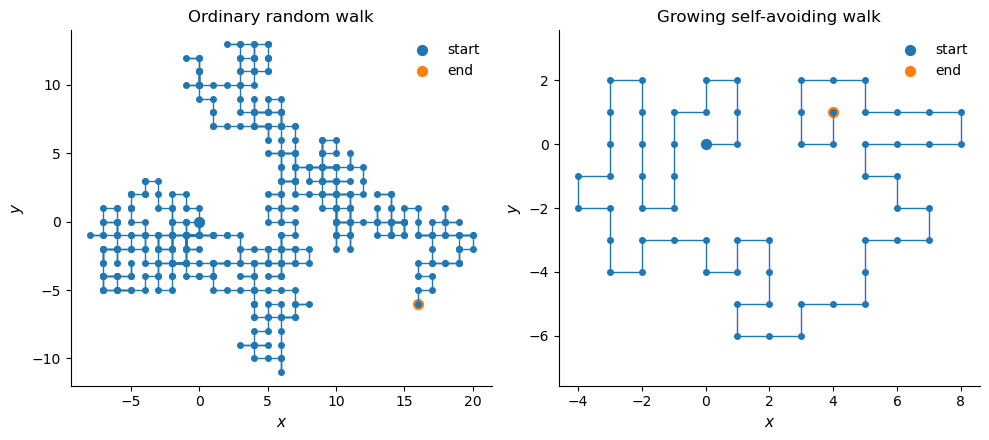

Ordinary random walk
Completed steps: 500
Distinct visited sites: 231

Growing self-avoiding walk
Completed steps: 63
Distinct visited sites: 64


In [7]:
# Simulate both movement rules up to the same step limit
n_steps = 500

rng_rw = np.random.default_rng()
rng_saw = np.random.default_rng()

path_rw = simulate_random_walk_2d(n_steps=n_steps, rng=rng_rw)
path_saw = simulate_growing_self_avoiding_walk(n_steps=n_steps, rng=rng_saw)

# Record how far each path actually ran
steps_rw = stopping_length(path_rw)
steps_saw = stopping_length(path_saw)

# Compare the two sample paths side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].plot(path_rw[:, 0], path_rw[:, 1], "o-", linewidth=1)
axes[0].scatter(path_rw[0, 0], path_rw[0, 1], s=50, label="start")
axes[0].scatter(path_rw[-1, 0], path_rw[-1, 1], s=50, label="end")
axes[0].set_title("Ordinary random walk")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].axis("equal")
axes[0].legend()

axes[1].plot(path_saw[:, 0], path_saw[:, 1], "o-", linewidth=1)
axes[1].scatter(path_saw[0, 0], path_saw[0, 1], s=50, label="start")
axes[1].scatter(path_saw[-1, 0], path_saw[-1, 1], s=50, label="end")
axes[1].set_title("Growing self-avoiding walk")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y$")
axes[1].axis("equal")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Ordinary random walk")
print("Completed steps:", steps_rw)
print("Distinct visited sites:", count_distinct_sites(path_rw))

print()

print("Growing self-avoiding walk")
print("Completed steps:", steps_saw)
print("Distinct visited sites:", count_distinct_sites(path_saw))

Both panels show one simulated path. The ordinary random walk completes all 500 steps, but it may visit the same site many times. The growing self-avoiding walk visits each site at most once and may stop early if it becomes trapped.

This comparison also explains why the position process alone is not Markov for the growing self-avoiding walk. The next move depends not only on the current position, but also on which sites have already been visited.

## Example 3: Distribution of the stopping length

For a growing self-avoiding walk, the number of completed steps is random. We write $L$ for the number of completed steps before the walk becomes trapped.

A single trapped path gives one value of $L$. To study its distribution, we repeat the simulation and record the stopping length and final distance. A large step limit is used as a numerical safeguard. Runs that reach this limit without becoming trapped are counted separately and are not treated as observations of $L$.

In [8]:
n_runs = 5000
n_steps_max = 1000

# Reuse one fresh generator for the repeated experiment
repeated_rng = np.random.default_rng()

# Store statistics only for runs that end by trapping
lengths = []
distances = []
unfinished_runs = 0

for _ in range(n_runs):

    path = simulate_growing_self_avoiding_walk(
        n_steps=n_steps_max,
        rng=repeated_rng
    )

    # Separate true trapping from the numerical stopping rule
    if is_trapped(path):
        lengths.append(stopping_length(path))
        distances.append(final_distance(path))
    else:
        unfinished_runs += 1

# Convert recorded values to arrays for summaries and plots
lengths = np.array(lengths)
distances = np.array(distances)

print("Number of simulations:", n_runs)
print("Maximum allowed number of steps:", n_steps_max)
print("Completed trapping runs:", len(lengths))
print("Runs reaching the numerical limit:", unfinished_runs)
print("Average stopping length:", lengths.mean())
print("Minimum stopping length:", lengths.min())
print("Maximum stopping length:", lengths.max())

Number of simulations: 5000
Maximum allowed number of steps: 1000
Completed trapping runs: 5000
Runs reaching the numerical limit: 0
Average stopping length: 71.4102
Minimum stopping length: 7
Maximum stopping length: 429


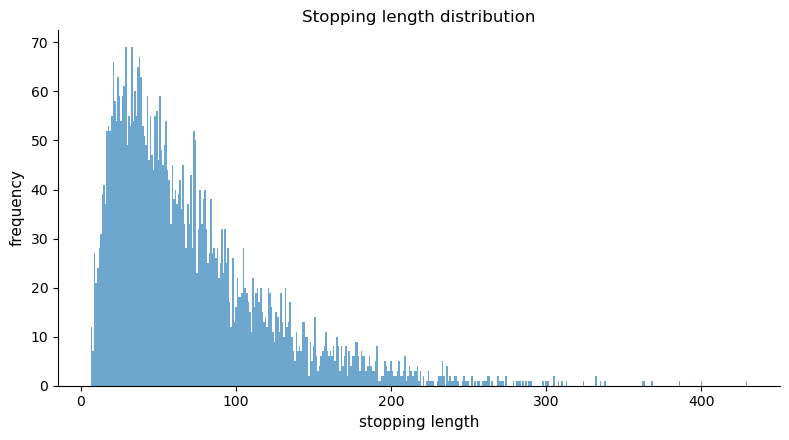

In [9]:
# Centre each histogram bin on an integer stopping length
plt.figure(figsize=FIGSIZE)

bins = np.arange(lengths.min(), lengths.max() + 2) - 0.5

plt.hist(
    lengths,
    bins=bins,
    alpha=HIST_ALPHA,
)

plt.xlabel("stopping length")
plt.ylabel("frequency")
plt.title("Stopping length distribution")
plt.tight_layout()
plt.show()

This histogram uses the runs that became trapped before the numerical limit. Each bar shows how often a stopping length occurred. The stopping length is highly variable, so the same local rule can produce paths of very different lengths.

Unlike the previous examples, this figure shows a distribution from repeated runs, not one sample path. The next example compares stopping length with final distance from the origin.


## Example 4: Stopping length and final distance

The same repeated simulations also record the final distance from the origin. The stopping length tells us how long the walk survives before it becomes trapped, while the final distance describes its endpoint.

These two quantities are related, but they are not the same. A long path may end far away, but it may also turn many times and finish relatively close to the origin.

In [10]:
# Reuse Example 3 so both figures describe the same runs
print("Number of simulations:", n_runs)
print("Completed trapping runs:", len(lengths))
print("Runs reaching the numerical limit:", unfinished_runs)
print("Average stopping length:", lengths.mean())
print("Average final distance:", distances.mean())
print("Maximum final distance:", distances.max())

Number of simulations: 5000
Completed trapping runs: 5000
Runs reaching the numerical limit: 0
Average stopping length: 71.4102
Average final distance: 11.866108698231486
Maximum final distance: 70.32780389006896


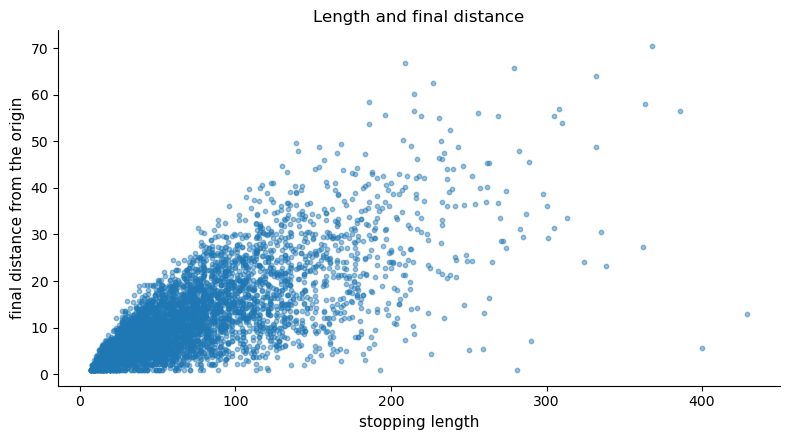

In [11]:
# Compare two summaries recorded from each trapped path
plt.figure(figsize=FIGSIZE)

plt.scatter(
    lengths,
    distances,
    s=10,
    alpha=OVERLAP_ALPHA
)

plt.xlabel("stopping length")
plt.ylabel("final distance from the origin")
plt.title("Length and final distance")
plt.tight_layout()
plt.show()

This figure uses the same repeated simulations as the histogram. Each point represents one walk that became trapped before the numerical limit. The horizontal axis records the stopping length $L$, while the vertical axis records the final distance from the origin.

Longer walks have more opportunity to move far away, but the relation is not deterministic. Some long paths still end relatively close to the origin because the path can turn many times before it becomes trapped.

## Example 5: A simple obstacle interpretation

As a small application style variation, some lattice sites are blocked before the walk starts. The walk cannot enter these sites, and it also cannot revisit its own previous sites.

At each step, the walk moves to an allowed nearest neighbour if one exists. If all nearest neighbours are blocked or already visited, the walk stops. This is not a new theory, but a simple way to view the same self avoiding rule in a constrained environment.




In [26]:
def simulate_self_avoiding_walk_with_obstacles(
    n_steps,
    blocked_sites,
    start=(0, 0),
    rng=None
):
    """Simulate a growing self-avoiding walk with blocked sites."""
    if rng is None:
        rng = np.random.default_rng()

    blocked_sites = set(blocked_sites)

    if start in blocked_sites:
        raise ValueError("The starting site cannot be blocked.")

    path = [start]
    visited = {start}

    for _ in range(n_steps):
        x, y = path[-1]

        # Nearest neighbours
        neighbours = [
            (x + 1, y),
            (x - 1, y),
            (x, y + 1),
            (x, y - 1),
        ]

        # Avoid old sites and blocked sites
        available = [
            site for site in neighbours
            if site not in visited and site not in blocked_sites
        ]

        # Stop if no legal move exists
        if len(available) == 0:
            break

        # Choose one legal move
        next_site = available[rng.integers(len(available))]
        path.append(next_site)
        visited.add(next_site)

    return np.array(path)

In [29]:
# Create a vertical wall with one gap
blocked_sites = []

for y in range(-8, 9):
    if y != 0:
        blocked_sites.append((4, y))

blocked_sites = set(blocked_sites)

# Simulate one path in the fixed environment
obstacle_rng = np.random.default_rng()

path_obstacle = simulate_self_avoiding_walk_with_obstacles(
    n_steps=300,
    blocked_sites=blocked_sites,
    rng=obstacle_rng
)

# Check that both movement restrictions are respected
print("Number of blocked sites:", len(blocked_sites))
print("Number of completed steps:", stopping_length(path_obstacle))
print("All moves are nearest-neighbour moves:", check_nearest_neighbour_moves(path_obstacle))
print("Self-avoiding:", len(path_obstacle) == count_distinct_sites(path_obstacle))

Number of blocked sites: 16
Number of completed steps: 75
All moves are nearest-neighbour moves: True
Self-avoiding: True


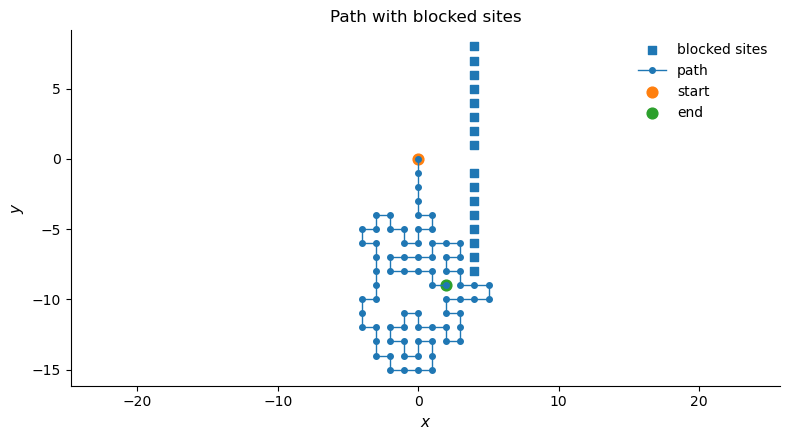

In [30]:
plt.figure(figsize=FIGSIZE)

# Plot the fixed environment before adding the random path
blocked_array = np.array(list(blocked_sites))

plt.scatter(
    blocked_array[:, 0],
    blocked_array[:, 1],
    marker="s",
    s=35,
    label="blocked sites"
)

# Draw the path through the constrained lattice
plt.plot(
    path_obstacle[:, 0],
    path_obstacle[:, 1],
    "o-",
    linewidth=1,
    label="path"
)

# Mark the start and endpoint separately
plt.scatter(
    path_obstacle[0, 0],
    path_obstacle[0, 1],
    s=60,
    label="start"
)

plt.scatter(
    path_obstacle[-1, 0],
    path_obstacle[-1, 1],
    s=60,
    label="end"
)

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Path with blocked sites")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

This figure shows one sample path in a constrained environment. The blocked sites are fixed before the simulation starts. The walk still follows the same basic rule: it moves to an allowed nearest neighbour whenever possible. The difference is that some sites are forbidden even if they have not been visited before.



## Summary

This module extends the ordinary random walk by adding a self avoiding rule. The current position alone is no longer enough to determine the next step, because the path history also matters.

One simulation gives one sample path, while repeated simulations show how the stopping length varies. The module therefore connects naturally to the random walk material and shows how a small change in the movement rule creates path dependence.